In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU is available and will be used: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU not found. The model will run on the CPU.")

GPU is available and will be used: NVIDIA GeForce RTX 4060


In [3]:
df = pd.read_csv('../Weather_Merged_CSVs/Paddy-2015-2019.csv')
df.head()

,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,Day Of Week,lookback_temp_mean,lookback_precip_sum
0,Kancheepuram,Acharapakkam,Paddy(Dhan)(Common),Adt 37,FAQ,1350.0,1660.0,1620.0,2018-12-12,2,28.799048,690.5
1,Thirunelveli,Ambasamudram,Paddy(Dhan)(Common),Ast 16,FAQ,1400.0,1600.0,1510.0,2016-08-11,3,28.895714,166.9
2,Thirunelveli,Ambasamudram,Paddy(Dhan)(Common),Ast 16,FAQ,1400.0,1600.0,1520.0,2016-10-07,4,29.713333,159.5
3,Thirunelveli,Ambasamudram,Paddy(Dhan)(Common),Ast 16,FAQ,1550.0,1750.0,1600.0,2018-11-28,2,28.605714,932.2
4,Thirunelveli,Ambasamudram,Paddy(Dhan)(Common),Ast 16,FAQ,1700.0,1900.0,1800.0,2018-02-05,0,27.895238,912.2


In [4]:
# Time Series Analysis 
df['Price Date'] = pd.to_datetime(df['Price Date'])
df.sort_values('Price Date', inplace=True)
df.set_index('Price Date', inplace=True)

# Feature Engineering
df['day_of_year'] = df.index.dayofyear
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['month'] = df.index.month


df.head()

,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Day Of Week,lookback_temp_mean,lookback_precip_sum,day_of_year,week_of_year,month
Price Date,,,,,,,,,,,,,,
2015-01-02,Villupuram,Thiryagadurgam,Paddy(Dhan)(Common),Other,FAQ,1508.0,1696.0,1602.0,4,28.454286,859.7,2,1,1
2015-01-02,Vellore,Ammoor,Paddy(Dhan)(Common),Ponni - Super,FAQ,1416.0,1543.0,1480.0,4,27.009048,750.3,2,1,1
2015-01-02,Villupuram,Thirukovilur,Paddy(Dhan)(Common),Ponni - A,FAQ,1509.0,1938.0,1638.0,4,28.454286,859.7,2,1,1
2015-01-02,Thiruvannamalai,Desur,Paddy(Dhan)(Common),Adt 37,FAQ,1347.0,1497.0,1415.0,4,26.839048,917.5,2,1,1
2015-01-02,Villupuram,Thirukovilur,Paddy(Dhan)(Common),Adt 39,FAQ,1049.0,1638.0,1537.0,4,28.454286,859.7,2,1,1


In [5]:
categorical_cols = ['District Name', 'Market Name', 'Commodity', 'Variety', 'Grade']
for col in categorical_cols:
    encoder = LabelEncoder()
    # Fit the encoder to the column and transform the text to numbers (e.g., 'Coimbatore', 'Theni' -> 0, 1)
    df[col] = encoder.fit_transform(df[col])
df.head()

,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Day Of Week,lookback_temp_mean,lookback_precip_sum,day_of_year,week_of_year,month
Price Date,,,,,,,,,,,,,,
2015-01-02,25,109,0,20,0,1508.0,1696.0,1602.0,4,28.454286,859.7,2,1,1
2015-01-02,24,3,0,30,0,1416.0,1543.0,1480.0,4,27.009048,750.3,2,1,1
2015-01-02,25,102,0,27,0,1509.0,1938.0,1638.0,4,28.454286,859.7,2,1,1
2015-01-02,20,26,0,2,0,1347.0,1497.0,1415.0,4,26.839048,917.5,2,1,1
2015-01-02,25,102,0,4,0,1049.0,1638.0,1537.0,4,28.454286,859.7,2,1,1


In [6]:
# Scales values between 0 and 1 for each column
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)
df_scaled.head()

,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Day Of Week,lookback_temp_mean,lookback_precip_sum,day_of_year,week_of_year,month
0,0.961538,0.789855,0.0,0.571429,0.0,0.212694,0.099437,0.220418,0.666667,0.659205,0.590694,0.00274,0.0,0.0
1,0.923077,0.021739,0.0,0.857143,0.0,0.199718,0.090467,0.203632,0.666667,0.463978,0.502773,0.00274,0.0,0.0
2,0.961538,0.739130,0.0,0.771429,0.0,0.212835,0.113626,0.225371,0.666667,0.659205,0.590694,0.00274,0.0,0.0
3,0.769231,0.188406,0.0,0.057143,0.0,0.189986,0.087770,0.194689,0.666667,0.441014,0.637145,0.00274,0.0,0.0
4,0.961538,0.739130,0.0,0.114286,0.0,0.147955,0.096037,0.211475,0.666667,0.659205,0.590694,0.00274,0.0,0.0


In [7]:
def create_sequences(data, n_steps, target_column):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data.iloc[i:(i + n_steps)].values)
        y.append(data.iloc[i + n_steps][target_column])
    return np.array(X), np.array(y).reshape(-1, 1)

In [8]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_prob):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_prob)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

In [9]:
# Tuning n_steps
n_steps_to_test = [7, 14, 21, 30, 60]
RMSE_results = {}
target_column = 'Modal Price (Rs./Quintal)'

best_n_steps = -1
best_nrmse = float('inf')
best_predictions = None
best_actuals = None

for n_steps in n_steps_to_test:
    print("-" * 50)
    print(f"Testing with n_steps = {n_steps}")
    start_time = time.time()

    # 1. Create sequences for the current n_steps
    X, y = create_sequences(df_scaled, n_steps, target_column)

    # 2. Split data and create PyTorch Tensors
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    X_train_tensor = torch.from_numpy(X_train).float()
    y_train_tensor = torch.from_numpy(y_train).float()
    X_test_tensor = torch.from_numpy(X_test).float()
    y_test_tensor = torch.from_numpy(y_test).float()

    # 3. Create DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 4. Initialize the Model, Loss, and Optimizer
    input_size = X_train.shape[2]
    model = GRUModel(input_size, hidden_size=50, num_layers=2, output_size=1, dropout_prob=0.2).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # 5. Train the Model
    num_epochs = 50
    for epoch in range(num_epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # 6. Make Predictions
    model.eval()
    all_predictions = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            all_predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(all_predictions)

    # 7. Inverse Transform to Get Actual Price Values
    price_col_index = df_scaled.columns.get_loc(target_column)
    
    # Inverse predictions
    dummy_pred = np.zeros((len(predictions), df_scaled.shape[1]))
    dummy_pred[:, price_col_index] = predictions.flatten()
    inversed_predictions = scaler.inverse_transform(dummy_pred)[:, price_col_index]
    
    # Inverse actual values
    dummy_actual = np.zeros((len(y_test), df_scaled.shape[1]))
    dummy_actual[:, price_col_index] = y_test.flatten()
    inversed_actual = scaler.inverse_transform(dummy_actual)[:, price_col_index]
    
    # 8. Calculate and Store RMSE
    rmse = np.sqrt(mean_squared_error(inversed_actual, inversed_predictions))
    mean_actual_price = np.mean(inversed_actual)
    nrmse = rmse / mean_actual_price
    RMSE_results[n_steps] = {'rmse': rmse, 'nrmse': nrmse}

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_n_steps = n_steps
        best_predictions = inversed_predictions
        best_actuals = inversed_actual

    end_time = time.time()
    print(f"n_steps = {n_steps} | RMSE = {rmse:.2f} | nRMSE (%) = {nrmse * 100:.2f}% | Time = {end_time - start_time:.2f}s")


--------------------------------------------------
Testing with n_steps = 7
n_steps = 7 | RMSE = 316.01 | nRMSE (%) = 20.64% | Time = 115.28s
--------------------------------------------------
Testing with n_steps = 14
n_steps = 14 | RMSE = 312.84 | nRMSE (%) = 20.43% | Time = 109.46s
--------------------------------------------------
Testing with n_steps = 21
n_steps = 21 | RMSE = 314.08 | nRMSE (%) = 20.51% | Time = 108.42s
--------------------------------------------------
Testing with n_steps = 30
n_steps = 30 | RMSE = 311.66 | nRMSE (%) = 20.35% | Time = 109.47s
--------------------------------------------------
Testing with n_steps = 60
n_steps = 60 | RMSE = 313.01 | nRMSE (%) = 20.44% | Time = 111.71s


In [10]:
print("\n" + "="*60)
print("Hyperparameter Tuning Results:")
print("="*60)
print(f"{'n_steps':<10} | {'RMSE (Rs./Quintal)':<20} | {'nRMSE (%)':<15}")
print("-" * 55)
for n_steps, metrics in RMSE_results.items():
    print(f"{n_steps:<10} | {metrics['rmse']:<20.2f} | {metrics['nrmse'] * 100:<15.2f}%")
print("-" * 55)
print(f"Best n_steps found: {best_n_steps} with an nRMSE of {best_nrmse * 100:.2f}%")
print("="*60)


Hyperparameter Tuning Results:
n_steps    | RMSE (Rs./Quintal)   | nRMSE (%)      
-------------------------------------------------------
7          | 316.01               | 20.64          %
14         | 312.84               | 20.43          %
21         | 314.08               | 20.51          %
30         | 311.66               | 20.35          %
60         | 313.01               | 20.44          %
-------------------------------------------------------
Best n_steps found: 30 with an nRMSE of 20.35%



Generating plot for the best performing GRU model...


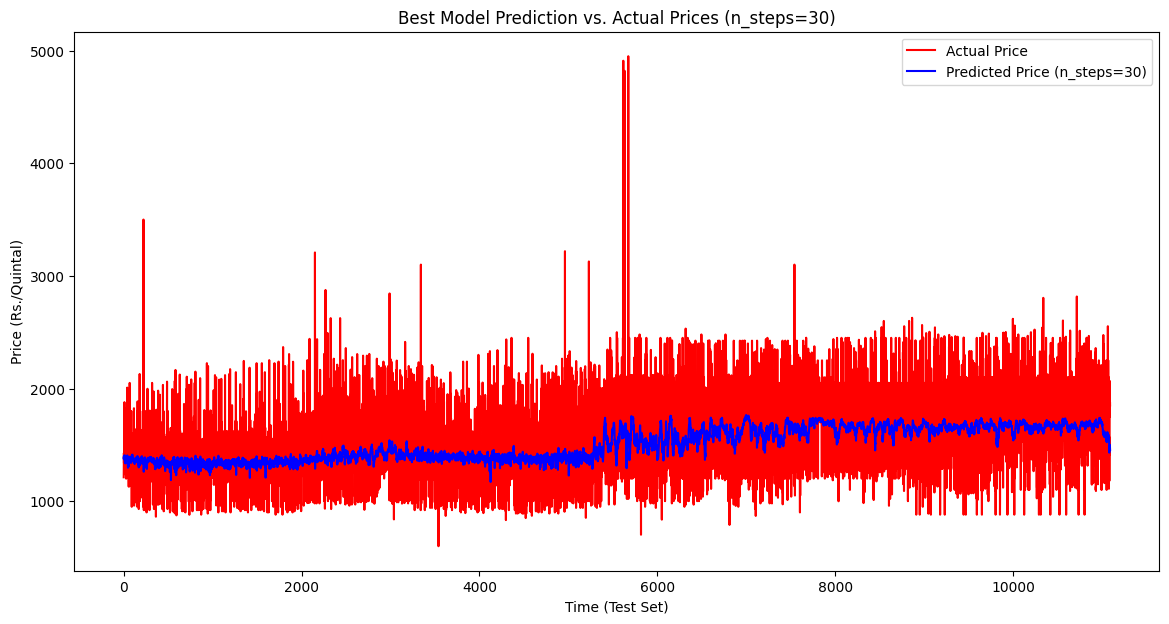

In [11]:
if best_predictions is not None and best_actuals is not None:
    print("\nGenerating plot for the best performing GRU model...")
    plt.figure(figsize=(14, 7))
    plt.plot(best_actuals, color='red', label=f'Actual Price')
    plt.plot(best_predictions, color='blue', label=f'Predicted Price (n_steps={best_n_steps})')
    plt.title(f'Best Model Prediction vs. Actual Prices (n_steps={best_n_steps})')
    plt.xlabel('Time (Test Set)')
    plt.ylabel('Price (Rs./Quintal)')
    plt.legend()
else:
    print("No predictions were saved to plot.")